This notebook compiles a dataset of m_star values and features based on GOTM SMC output. Currently (Oct. 8th, 2025), the features include mean boundary layer depth, constant zonal wind stress, constant heat flux and the local Coriolis frequency. The mean boundary layer depth is averaged over inertial periods of SMC simulations with the total length of 10 days. The first inertial period is discarded from the mean calculation. The m_star mean values are computed in the same fashion.

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import json

import torch

In [3]:
def compute_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(np.pi * latitude / 180)

In [4]:
def compute_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(np.pi * latitude / 180)

In [5]:
data_directory = '../m_star_dataset'
suffix = "ows_papa_2015_sane23.npy"

In [6]:
bl = np.load(f"{data_directory}/bl_{suffix}")
B = np.load(f"{data_directory}/buoyancy_flux_{suffix}")
heat_flux = np.load(f"{data_directory}/heat_flux_{suffix}")
u_star = np.load(f"{data_directory}/u_star_{suffix}")
# m_star = np.load(f"{data_directory}/reduced_m_star_{suffix}")
M = np.load(f"{data_directory}/M_{suffix}")
u_surf = np.load(f"{data_directory}/u_surf_{suffix}")
v_surf = np.load(f"{data_directory}/v_surf_{suffix}")
tx = np.load(f"{data_directory}/tx_surf_{suffix}")
ty = np.load(f"{data_directory}/ty_surf_{suffix}")
u_bl = np.load(f"{data_directory}/u_bl_{suffix}")
v_bl = np.load(f"{data_directory}/v_bl_{suffix}")
SS_bl = np.load(f"{data_directory}/SS_bl_{suffix}")
NN_bl = np.load(f"{data_directory}/NN_bl_{suffix}")

In [5]:
# NN_bl = np.where(NN_bl <= 0, np.nanmin(abs(np.where(NN_bl == 0, np.nan, NN_bl))), NN_bl)

(array([8.400e+01, 6.340e+02, 2.689e+03, 4.565e+03, 6.160e+02, 1.300e+02,
        3.200e+01, 6.000e+00, 4.000e+00, 1.000e+00]),
 array([-2.37756893e-07, -1.74667946e-07, -1.11579013e-07, -4.84900795e-08,
         1.45988679e-08,  7.76878153e-08,  1.40776734e-07,  2.03865682e-07,
         2.66954629e-07,  3.30043548e-07,  3.93132495e-07]),
 <BarContainer object of 10 artists>)

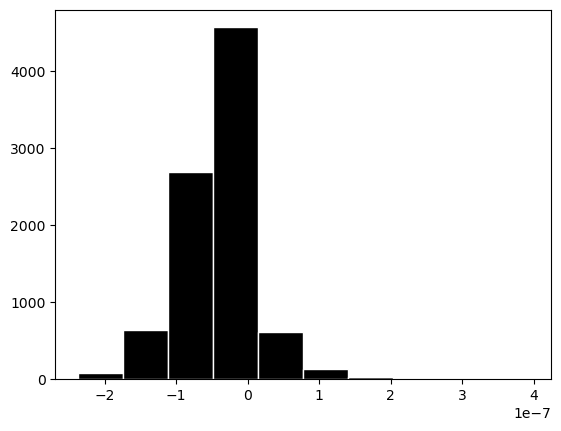

In [9]:
plt.hist(B, color="black", ec="white")

In [16]:
surface_magnitude = np.sqrt(tx**2+ty**2)*np.sqrt(u_surf**2+v_surf**2)
surface_angle = np.arccos((u_surf*tx + v_surf*ty)/(np.sqrt(u_surf**2+v_surf**2)*(np.sqrt(tx**2+ty**2))))
surface_ekin_input = surface_magnitude*np.cos(surface_angle)

In [57]:
coriolis_freq.shape

(8761,)

In [17]:
coriolis_freq = np.repeat(compute_f(latitude=50), len(B))

In [18]:
bls_im1 = bl[:-1]

In [20]:
torch_dataset_name = f"ows_papa_2015_sane23_dataset_M_target.pt"
dataset = torch.tensor(np.array([
    coriolis_freq[1:], u_star[1:], bl[1:], B[1:], surface_magnitude[1:], surface_angle[1:], surface_ekin_input[1:], bls_im1, u_bl[1:], v_bl[1:], SS_bl[1:], NN_bl[1:], M[1:]
]))
torch.save(dataset, os.path.join(data_directory, torch_dataset_name))